In [283]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [284]:
# load data
df_waterstress = pd.read_csv("Machine_Learning/AQUASTAT Dissemination System/AQUASTAT Dissemination System 2.csv")
df_waterstress.head()

,VariableGroup,Subgroup,Variable,Area,Year,Value,Unit,Symbol,IsAggregate
0,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2015,554.004007,current US$/inhab,X,False
1,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2016,526.164709,current US$/inhab,X,False
2,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2017,534.020133,current US$/inhab,X,False
3,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2018,513.981256,current US$/inhab,X,False
4,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2019,512.910125,current US$/inhab,X,False


In [285]:
# evaluating data for regression
print(df_waterstress['Area'].unique())
print(df_waterstress['Year'].unique())
print(df_waterstress['Variable'].unique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' "Côte d'Ivoire" "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran (

In [286]:
# pivoting data 
df_waterstress = df_waterstress.pivot_table(
    index=["Area", "Year"],
    columns="Variable",
    values="Value"
).reset_index()

df_waterstress.head(8)

Variable,Area,Year,Agricultural water withdrawal,GDP per capita,Industrial water withdrawal,Municipal water withdrawal,SDG 6.4.1. Water Use Efficiency,SDG 6.4.2. Water Stress,Total population
0,Afghanistan,2015,20.0,554.004007,0.1695,0.2034,0.886913,54.757019,33831.764
1,Afghanistan,2016,20.0,526.164709,0.1695,0.2034,0.761670,54.757019,34700.612
2,Afghanistan,2017,20.0,534.020133,0.1695,0.2034,0.774685,54.757019,35688.935
3,Afghanistan,2018,20.0,513.981256,0.1695,0.2034,0.803860,54.757019,36743.039
4,Afghanistan,2019,20.0,512.910125,0.1695,0.2034,0.876542,54.757019,37856.121
5,Afghanistan,2020,20.0,512.749930,0.1695,0.2034,0.835661,54.757019,39068.979
6,Afghanistan,2021,20.0,378.082892,0.1695,0.2034,0.641497,54.757019,40000.412
7,Afghanistan,2022,20.0,344.649112,0.1695,0.2034,0.599199,54.757019,40578.842


In [287]:
# list of countries from 'Area' to exclude (regions, socio-economic groups)
excluded_regions = ['World', 'Europe', 'Asia', 'High-income countries', 'Low-income countries','European Union (27)', 
                    'Least Developed Countries', 'Western Asia', 'Sub-Saharan Africa', 'Southern Asia', 'South-eastern Asia',
                    'Oceania', 'Oceania (excluding Australia and New Zealand)', 'Northern Africa',
                    'Northern Africa and Western Asia','Northern America', 'Latin America and the Caribbean',
                    'Land Locked Developing Countries', 'Europe and Northern America', 'Eastern Asia', 
                    'Eastern and South-Eastern Asia', 'Central Asia','Central and Southern Asia']
waterstress_clean = df_waterstress[~df_waterstress["Area"].isin(excluded_regions)]

In [288]:
# target is 'SDG 6.4.2. Water Stress (t+1)'
waterstress_clean = waterstress_clean.sort_values(by=["Area", "Year"])
waterstress_clean["Water Stress (t+1)"] = waterstress_clean.groupby("Area")["SDG 6.4.2. Water Stress"].shift(-1)

# dropping 'SDG 6.4.2. Water Stress' because target is created
waterstress_clean = waterstress_clean.drop(columns=["SDG 6.4.2. Water Stress"])

In [289]:
# check missing values
print("\nMissing values per column:")
print(waterstress_clean.isnull().sum())

waterstress_clean.describe()


Missing values per column:
Variable
Area                                 0
Year                                 0
Agricultural water withdrawal      161
GDP per capita                      48
Industrial water withdrawal        161
Municipal water withdrawal         136
SDG 6.4.1. Water Use Efficiency    257
Total population                     0
Water Stress (t+1)                 356
dtype: int64


Variable,Year,Agricultural water withdrawal,GDP per capita,Industrial water withdrawal,Municipal water withdrawal,SDG 6.4.1. Water Use Efficiency,Total population,Water Stress (t+1)
count,1616.000000,1455.000000,1568.000000,1455.000000,1480.000000,1359.000000,1.616000e+03,1260.000000
mean,2018.500000,15.958126,15728.079667,3.500208,2.806815,47.150887,3.887571e+04,68.083594
std,2.291997,62.554467,26085.672454,18.091449,10.123796,111.770492,1.452721e+05,319.952508
min,2015.000000,0.000000,262.001758,0.000000,0.004800,0.599199,5.100000e-01,0.027446
25%,2016.750000,0.080660,2025.854000,0.025000,0.111000,6.423847,1.656738e+03,3.671604
50%,2018.500000,1.071000,5922.982813,0.170000,0.376900,14.561863,8.368349e+03,10.866669
75%,2020.250000,7.563000,17761.483231,1.400000,1.274425,47.083413,2.897959e+04,39.553314
max,2022.000000,688.000000,240535.043309,209.700000,117.010000,1394.294841,1.458175e+06,3850.500000


In [290]:
# dropping rows with missing target
waterstress_clean = waterstress_clean.dropna(subset=['Water Stress (t+1)'])

columns = ['Agricultural water withdrawal', 'GDP per capita','Industrial water withdrawal', 'Municipal water withdrawal', 
          'SDG 6.4.1. Water Use Efficiency','Total population']

# fill in missing values with median (for each country rather than global due to country extreme differences)
waterstress_clean[columns] = waterstress_clean.groupby("Area")[columns].transform(
    lambda x: x.fillna(x.median()))

# fill in missing values with global median (for remaining values)
waterstress_clean[columns] = waterstress_clean[columns].fillna(waterstress_clean[columns].median())

# check skewness for each feature
print(waterstress_clean.drop(columns=["Area", "Year", "Water Stress (t+1)"]).skew())


Variable
Agricultural water withdrawal      8.098340
GDP per capita                     2.329529
Industrial water withdrawal        9.564495
Municipal water withdrawal         7.522706
SDG 6.4.1. Water Use Efficiency    8.374228
Total population                   8.072408
dtype: float64


In [291]:
# log-transform all features (all highly-skewed)
for col in ['Agricultural water withdrawal', 'GDP per capita', 'Industrial water withdrawal', 'Municipal water withdrawal', 
            'SDG 6.4.1. Water Use Efficiency','Total population']:
    waterstress_clean[col] = np.log1p(waterstress_clean[col])
    
waterstress_clean.head()

Variable,Area,Year,Agricultural water withdrawal,GDP per capita,Industrial water withdrawal,Municipal water withdrawal,SDG 6.4.1. Water Use Efficiency,Total population,Water Stress (t+1)
0,Afghanistan,2015,3.044522,6.318975,0.156576,0.185151,0.634942,10.429185,54.757019
1,Afghanistan,2016,3.044522,6.267513,0.156576,0.185151,0.566262,10.454541,54.757019
2,Afghanistan,2017,3.044522,6.282304,0.156576,0.185151,0.573623,10.482624,54.757019
3,Afghanistan,2018,3.044522,6.244131,0.156576,0.185151,0.589929,10.511731,54.757019
4,Afghanistan,2019,3.044522,6.242048,0.156576,0.185151,0.629431,10.541574,54.757019


In [292]:
# target = 'SDG 6.4.2. Water Stress (t+1)'

X = waterstress_clean.drop(columns=['Area', 'Year', 'Water Stress (t+1)']) 
y = waterstress_clean['Water Stress (t+1)'] #features

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (1260, 6), y shape: (1260,)


In [293]:
# defining percentage of test size after train-test split
test_size = 0.2  # 20% used for testing

# random seed for reproducibility
random_state = 42  

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (1008, 6), y_train shape: (1008,)
X_test shape: (252, 6), y_test shape: (252,)


In [294]:
regression_tree = DecisionTreeRegressor(max_depth=10, random_state=42)  # Example hyperparameters

# fit the model on the training data
regression_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [295]:
# make predictions
y_pred_cart = regression_tree.predict(X_test)
y_pred_cart

array([6.27160204e+01, 2.43663124e+00, 6.55949519e+00, 8.17142857e+02,
       3.94075282e-01, 4.38253177e+00, 1.53858771e+01, 8.74182869e+00,
       5.97885851e-01, 3.48892225e+01, 1.53858771e+01, 4.11572424e+00,
       6.78235294e+00, 1.50955980e+00, 1.53858771e+01, 2.22270080e+00,
       7.75599129e+01, 1.13213915e+01, 1.48158516e+02, 1.61335808e+01,
       1.24740125e+01, 5.07429960e+00, 4.99348109e+00, 5.27111751e+00,
       2.12001363e+01, 3.66436782e+01, 1.57844328e+00, 1.33706897e+02,
       3.53308874e-01, 6.27160204e+01, 1.23345817e+01, 5.08333333e+01,
       1.75048381e+01, 5.07429960e+00, 5.07429960e+00, 4.40042836e+01,
       3.96351575e+00, 3.92878262e+01, 1.09404602e+01, 3.85050000e+03,
       3.57500000e+03, 6.89437367e+01, 1.57844328e+00, 3.66454999e-01,
       2.45277406e+01, 1.33706897e+02, 5.97885851e-01, 1.57844328e+00,
       5.07429960e+00, 2.22270080e+00, 1.48158516e+02, 2.98426391e+01,
       3.70570168e+00, 6.20674867e+00, 3.94075282e-01, 2.91004798e+01,
      

In [296]:
# calculating Mean Squared Error (MSE) and R²
mse = mean_squared_error(y_test, y_pred_cart)
r2 = r2_score(y_test, y_pred_cart)
print(f'Mean Squared Error: {mse}')
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 6303.648563607913
R² Score: 0.97


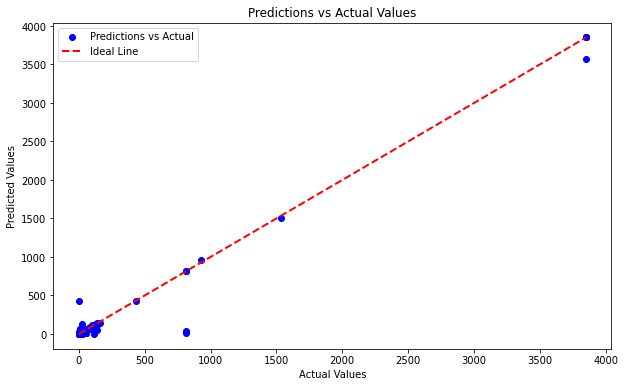

In [297]:
# plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_cart, color='blue', label='Predictions vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2, label='Ideal Line')
plt.title('Predictions vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

In [298]:
# trying random forest regression
random_forest_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)  # Example hyperparameters

# fitting the model on the training data
random_forest_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [299]:
# make predictions
y_pred_rf = random_forest_model.predict(X_test)
# convert probabilities to binary class labels
y_pred_rf

array([4.67254213e+01, 4.91265528e+00, 4.56484246e+01, 7.20499937e+02,
       1.65816537e+00, 4.89611070e+00, 4.19394589e+01, 1.07622430e+01,
       1.96421167e+00, 3.48072867e+01, 1.67663367e+01, 4.43944138e+00,
       1.02969301e+01, 1.49837476e+01, 3.22044576e+01, 2.58771619e+00,
       6.85859287e+01, 1.25309477e+01, 1.23544575e+02, 1.53536971e+01,
       9.60595394e+00, 4.66767869e+00, 1.89336513e+02, 1.65434434e+02,
       1.70757144e+01, 3.62024634e+01, 1.37958319e+00, 1.21578356e+02,
       1.67253593e+00, 3.47306925e+01, 1.93281664e+01, 5.33420299e+01,
       1.53257179e+01, 4.23332929e+00, 4.78188767e+00, 3.85910206e+01,
       4.06192028e+00, 2.35754208e+01, 1.25038052e+01, 3.58108366e+03,
       3.49822533e+03, 5.15839243e+01, 1.75230742e+00, 5.23481245e-01,
       2.55271694e+01, 1.22940476e+02, 1.08481956e+00, 1.74874493e+00,
       4.77737819e+00, 7.84316223e+01, 1.43150380e+02, 3.26868445e+01,
       8.54851519e+00, 9.53474792e+00, 1.98677685e+00, 4.82501623e+01,
      

In [300]:
# calculating MSE and R² for random forest model
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f'Mean Squared Error: {mse}')
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 3729.4899256700105
R² Score: 0.99


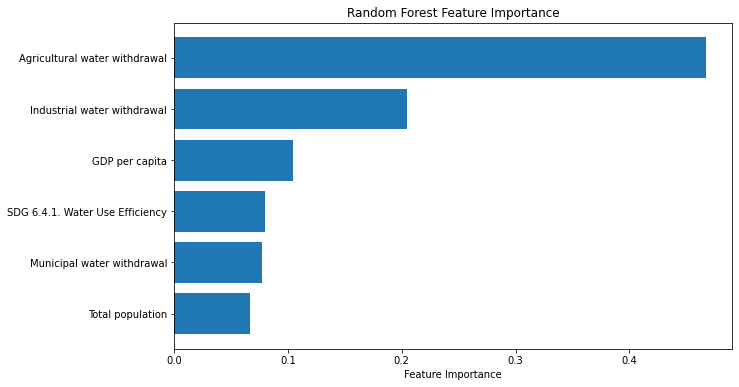

In [318]:
# getting feature importances from random forest model
feature_importances = random_forest_model.feature_importances_

# getting names of features
feature_names = list(X.columns)

# sorting features based on their importance
sorted_idx = feature_importances.argsort()

# plotting (feature importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align="center")
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

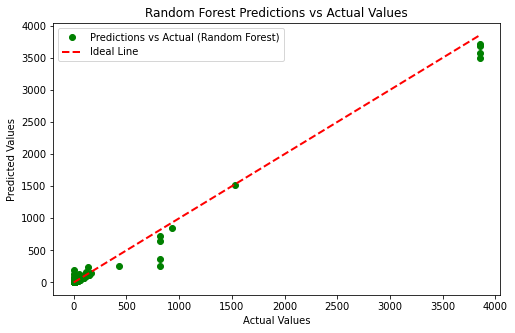

In [335]:
# plotting predictions vs actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, color='green', label='Predictions vs Actual (Random Forest)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2, label='Ideal Line')
plt.title('Random Forest Predictions vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.savefig('random_forest_regression_smaller_fig.png', dpi=300, bbox_inches='tight')
plt.show()

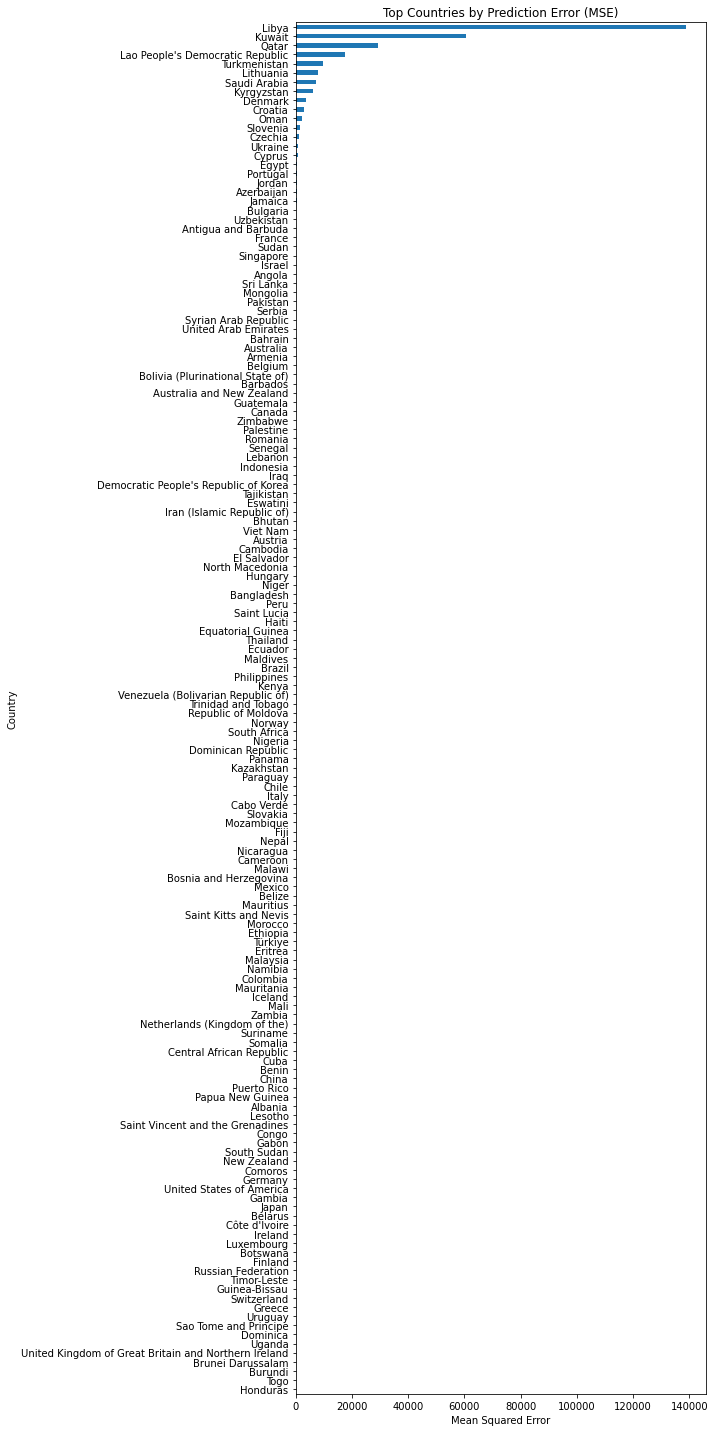

In [303]:
# copy test set and adding the predictions
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test
X_test_copy['Predicted'] = y_pred_rf
X_test_copy['Country'] = waterstress_clean.loc[X_test.index, 'Area']  # to get the name of the country

# grouping by country and calculating MSE
mse_country = X_test_copy.groupby('Country').agg(
    MSE=('Actual', lambda x: ((x - X_test_copy.loc[x.index, 'Predicted']) ** 2).mean()),
    Count=('Actual', 'count')
).sort_values('MSE')

# plotting figure (which countries the model struggled with)
plt.figure(figsize=(10, 20))
mse_country['MSE'].plot(kind='barh')
plt.title('Top Countries by Prediction Error (MSE)')
plt.xlabel('Mean Squared Error')
plt.tight_layout()
plt.show()

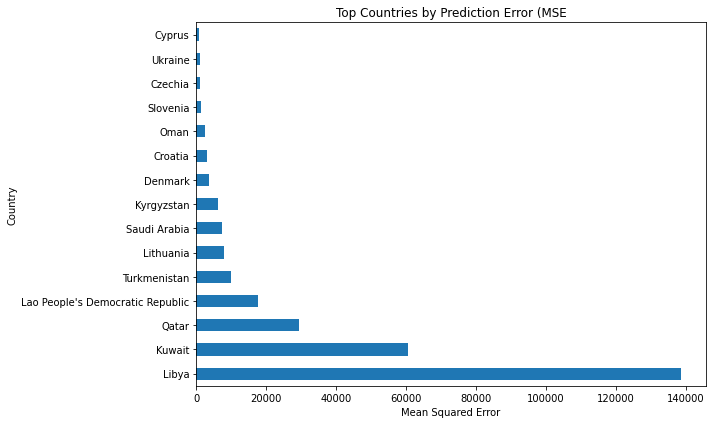

In [324]:
# copy test set and adding the predictions
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test
X_test_copy['Predicted'] = y_pred_rf
X_test_copy['Country'] = waterstress_clean.loc[X_test.index, 'Area']  # to get name of country

# grouping by country and calculating MSE
mse_country = X_test_copy.groupby('Country').agg(
    MSE=('Actual', lambda x: ((x - X_test_copy.loc[x.index, 'Predicted']) ** 2).mean()), 
    Count=('Actual', 'count')
).sort_values('MSE', ascending=False)

# showing only the top 15 countries
mse_country = mse_country.head(15)

# plotting
plt.figure(figsize=(10, 6))
mse_country['MSE'].plot(kind='barh')
plt.title('Top Countries by Prediction Error (MSE')
plt.xlabel('Mean Squared Error')
plt.tight_layout()
plt.savefig('mse_model_errors.png', dpi=300, bbox_inches='tight')
plt.show()


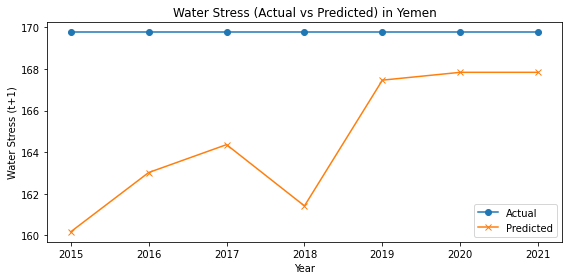

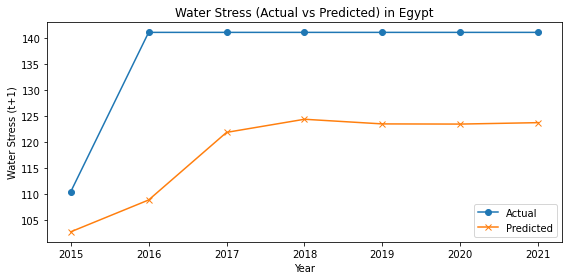

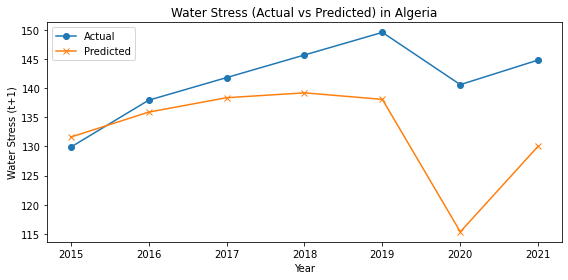

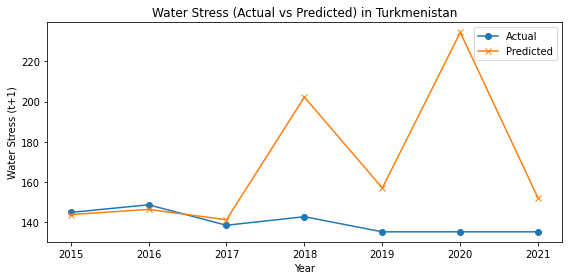

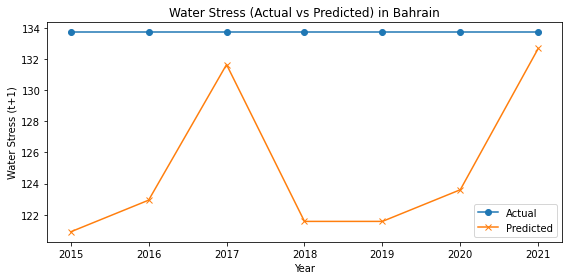

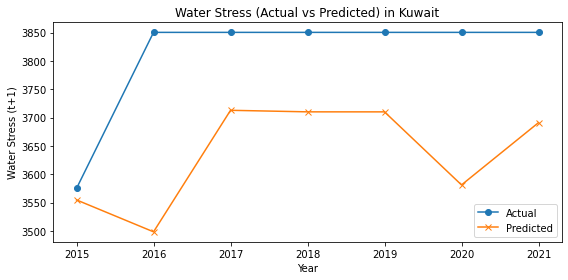

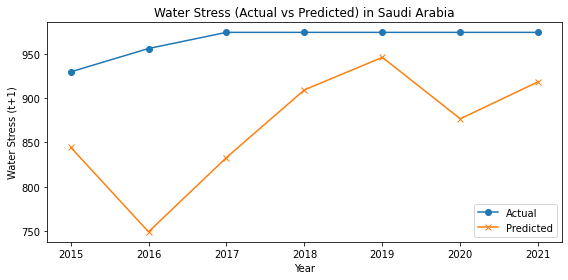

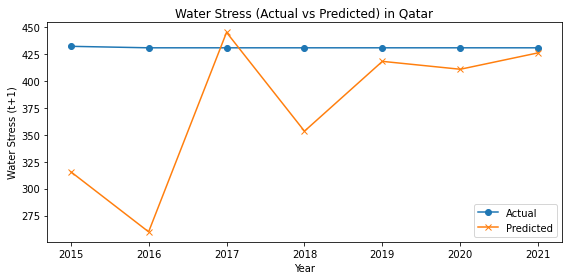

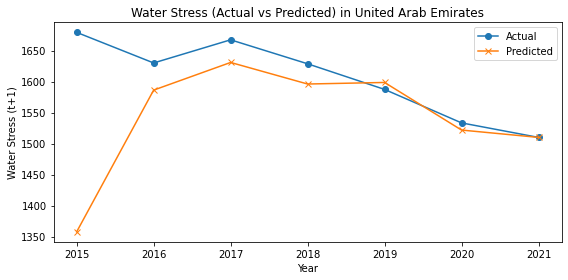

In [321]:
countries_top = ['Yemen', 'Egypt', 'Algeria', 'Turkmenistan', 'Bahrain', 'Kuwait', 'Saudi Arabia', 'Qatar', 
                 'United Arab Emirates']

for country in countries_top:
    subset = waterstress_clean[waterstress_clean['Area'] == country].copy()
    X_subset = subset.drop(columns=['Area', 'Year', 'Water Stress (t+1)'])

    # make predictions
    subset['Prediction'] = random_forest_model.predict(X_subset)

    # plotting actual vs. predicted
    plt.figure(figsize=(8, 4))
    plt.plot(subset['Year'], subset['Water Stress (t+1)'], label='Actual', marker='o')
    plt.plot(subset['Year'], subset['Prediction'], label='Predicted', marker='x')
    plt.title(f"Water Stress (Actual vs Predicted) in {country}")
    plt.xlabel("Year")
    plt.ylabel("Water Stress (t+1)")
    plt.legend()
    plt.tight_layout()
    plt.savefig('actual_vs_predicted_countries_top.png', dpi=300, bbox_inches='tight')
    plt.show()


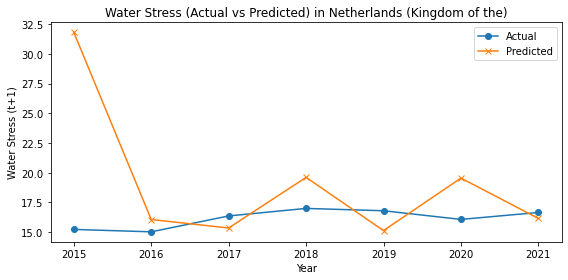

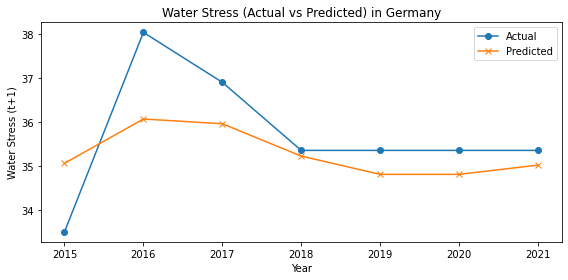

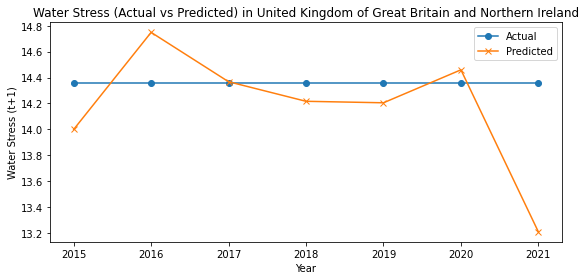

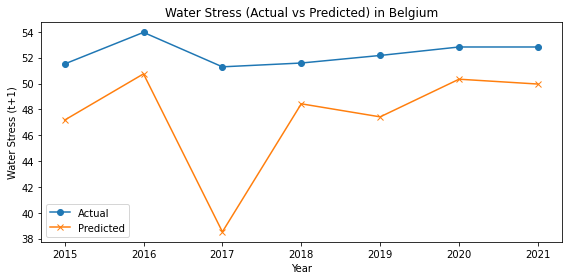

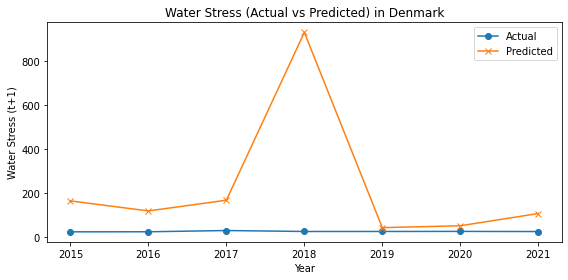

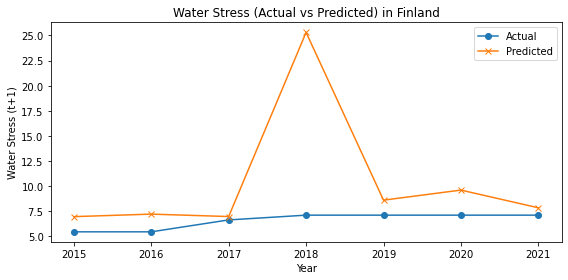

In [333]:
countries_similar_nl = ['Netherlands (Kingdom of the)', 'Germany', 'United Kingdom of Great Britain and Northern Ireland',
                        'Belgium', 'Denmark', 'Finland']

for country in countries_similar_nl:
    subset = waterstress_clean[waterstress_clean['Area'] == country].copy()
    X_subset = subset.drop(columns=['Area', 'Year', 'Water Stress (t+1)'])

    # make predictions
    subset['Prediction'] = random_forest_model.predict(X_subset)

    # plotting actual vs. predicted
    plt.figure(figsize=(8, 4))
    plt.plot(subset['Year'], subset['Water Stress (t+1)'], label='Actual', marker='o')
    plt.plot(subset['Year'], subset['Prediction'], label='Predicted', marker='x')
    plt.title(f"Water Stress (Actual vs Predicted) in {country}")
    plt.xlabel("Year")
    plt.ylabel("Water Stress (t+1)")
    plt.legend()
    plt.tight_layout()
    similar_country_save = country.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('.', '')
    plt.savefig(f'actual_vs_predicted_{similar_country_save}.png', dpi=300, bbox_inches='tight')


In [307]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [308]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# define and fitting XGBRegressor model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)  # hyperparameters
xgb_model.fit(X_train, y_train)

# making predictions
y_pred_xgb = xgb_model.predict(X_test)

# evaluate the model using MSE and R²
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
print(f'Mean Squared Error (XGBoost): {mse_xgb}')
print(f"R² Score: {r2:.2f}")


Mean Squared Error (XGBoost): 4114.534608427371
R² Score: 0.98


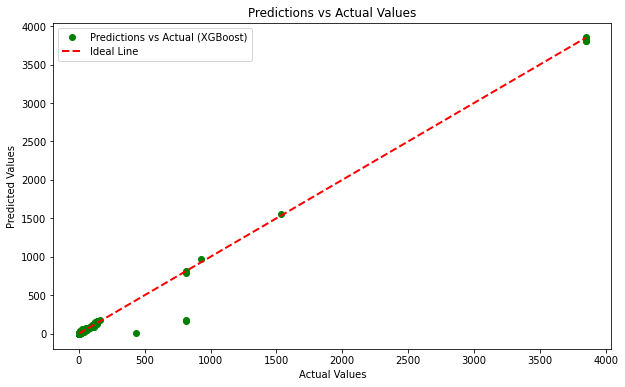

In [309]:
# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, color='green', label='Predictions vs Actual (XGBoost)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2, label='Ideal Line')
plt.title('Predictions vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()